# Analysis of LLM inference trade-offs across the edge continuum

This notebook contains the post-processing analysis for the measurement study presented in the paper. The goal is to compare LLM deployment configurations across edge-continuum hardware using the exported benchmark results. The analysis focuses on accuracy, model footprint, execution duration, prefill latency, decoding latency, energy consumption, and Pareto-efficient deployment choices.

The notebook uses two input files. `results.csv` contains the self-hosted measurements collected from the evaluated edge and near-edge devices. `results_chatgpt.csv` contains the cloud-hosted GPT-4o reference measurements, which are used only for accuracy, size, and duration comparisons where the corresponding data are available.


In [2]:
# Import pandas for reading the CSV files and preparing tabular benchmark data.
import pandas as pd

## Load self-hosted experiment results

The first dataset contains the measurements from the self-hosted LLM deployments. These include the Jetson Orin and the server-side execution modes used in the paper. The dataframe is the basis for the platform-level energy and latency plots that compare local edge execution, server GPU execution, and server CPU execution.


In [3]:
# Load the self-hosted benchmark results produced by the measurement pipeline.
# This table contains the Orin, Server CPU, and Server GPU measurements used in the plots below.
df = pd.read_csv("data/results.csv")

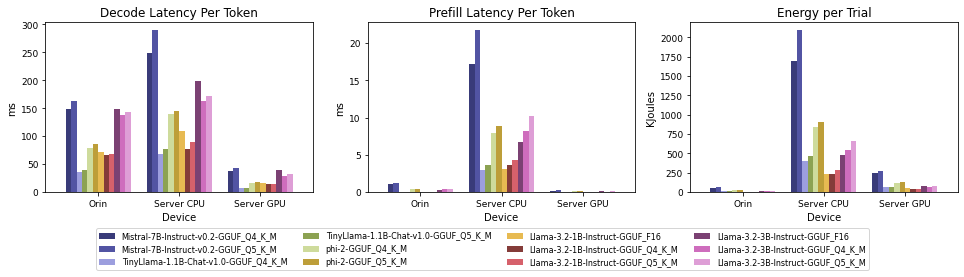

In [4]:
import matplotlib.pyplot as plt

# Optional: enforce the device order shown in your screenshot
device_order = ["Orin", "Server CPU", "Server GPU"]

# Preserve model order as it appears in the dataframe
model_order = df["model"].drop_duplicates().tolist()

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

plots = [
    {
        "column": "decode_latency_ms_per_token",
        "title": "Decode Latency Per Token",
        "ylabel": "ms",
        "scale": 1,
    },
    {
        "column": "prefill_latency_ms_per_token",
        "title": "Prefill Latency Per Token",
        "ylabel": "ms",
        "scale": 1,
    },
    {
        "column": "total_energy_system_J",
        "title": "Energy per Trial",
        "ylabel": "KJoules",
        "scale": 1 / 1000,
    },
]

for ax, spec in zip(axes, plots):
    pivot = (
        df.groupby(["device", "model"])[spec["column"]]
        .mean()
        .mul(spec["scale"])
        .unstack()
        .reindex(index=device_order)
        .reindex(columns=model_order)
    )

    pivot.plot.bar(
        ax=ax,
        width=0.8,
        colormap="tab20b",
        legend=False
    )

    ax.set_title(spec["title"], fontsize=12)
    ax.set_ylabel(spec["ylabel"], fontsize=10)
    ax.set_xlabel("Device", fontsize=10)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="both", labelsize=9)

# Get legend entries from the last subplot
handles, labels = axes[-1].get_legend_handles_labels()

# Add one shared legend below all plots
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.08),
    ncol=4,
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.35)
plt.savefig("rq2.png")
plt.show()

## Energy consumption per trial

This plot aggregates the measured total system energy by device and model. Energy is converted from joules to kilojoules to make the scale easier to read. The purpose of this figure is to compare how much energy each deployment configuration consumes over the benchmark trial.

In the paper, this analysis supports the observation that CPU-only execution is energy-inefficient for the studied workload because long execution time dominates total energy, while the Jetson Orin can achieve lower energy values due to its lower platform power.


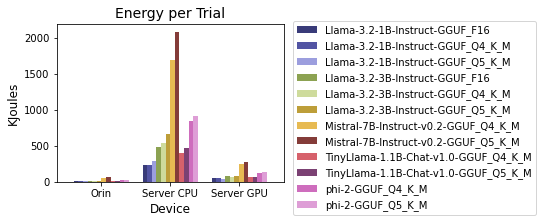

In [5]:
# Import plotting libraries used by the analysis figures.
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the mean total energy per device and model.
# The raw measurements are stored in joules, so the values are divided by 1000 to report kilojoules.
pivot = (df.groupby(["device", "model"]).total_energy_system_J.mean()/1000).unstack()

# Plot the energy comparison as a grouped bar chart, with one group per deployment device.
ax = pivot.plot.bar(
    figsize=(7.7, 3.2),
    width=0.8,
    colormap="tab20b"
)

# Configure the chart title and axis labels used in the paper-style visualization.
ax.set_title("Energy per Trial", fontsize=14)

ax.set_ylabel("KJoules", fontsize=12)
ax.set_xlabel("Device", fontsize=12)
ax.tick_params(axis='x', rotation=0)

# Move the legend outside the plot so that the model names do not overlap with the bars.
ax.legend( loc='upper left', bbox_to_anchor=(1.02, 1.05))
plt.tight_layout()

plt.show()


## Prefill latency per input token

This plot reports the average prefill latency per token for each model and device. Prefill latency captures the cost of processing the input prompt before output generation begins. This metric is important for interactive question-answering workloads because long prompts can increase the delay before the first generated token appears.

The comparison is used to show that GPU execution, especially on the server GPU, provides much lower prompt-processing latency than CPU-only execution, while the Orin remains a competitive edge-side option.


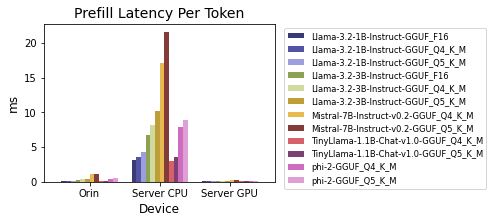

In [6]:
# Import plotting libraries used by the analysis figures.
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the mean prefill latency per input token for each device and model.
# Prefill latency captures the prompt-processing phase before token generation starts.
pivot = (df.groupby(["device", "model"]).prefill_latency_ms_per_token.mean()).unstack()

# Plot the prefill-latency comparison as a grouped bar chart.
ax = pivot.plot.bar(
    figsize=(7, 3.2),
    width=0.8,
    colormap="tab20b"
)

# Configure the chart title and axis labels.
ax.set_title("Prefill Latency Per Token", fontsize=14)

ax.set_ylabel("ms", fontsize=12)
ax.set_xlabel("Device", fontsize=12)
ax.tick_params(axis='x', rotation=0)

# Place the legend outside the plotting area to keep all model labels visible.
ax.legend(fontsize='small', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()

plt.show()


## Decode latency per generated token

This plot reports the average decoding latency per generated token. It captures how quickly each deployment can generate output tokens after the prompt has been processed. Lower values indicate more responsive streaming behavior.

This is one of the main latency metrics used in the paper because it directly affects the token arrival rate observed by users in interactive LLM services.


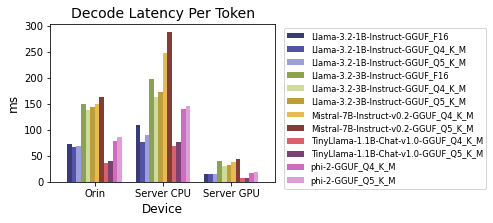

In [7]:
# Import plotting libraries used by the analysis figures.
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the mean decoding latency per generated token for each device and model.
# This metric reflects the compute-side token generation speed.
pivot = (df.groupby(["device", "model"]).decode_latency_ms_per_token.mean()).unstack()

# Plot the decode-latency comparison as a grouped bar chart.
ax = pivot.plot.bar(
    figsize=(7, 3.2),
    width=0.8,
    colormap="tab20b"
)

# Configure the chart title and axis labels.
ax.set_title("Decode Latency Per Token", fontsize=14)

ax.set_ylabel("ms", fontsize=12)
ax.set_xlabel("Device", fontsize=12)
ax.tick_params(axis='x', rotation=0)

# Place the legend outside the plotting area to keep the model names readable.
ax.legend(fontsize='small', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()

plt.show()


## Load cloud reference results

The second dataset contains the GPT-4o cloud reference measurements. The cloud measurements are not used in the energy analysis because the cloud API does not expose comparable hardware-level power or energy metrics. They are included in the later plots as an accuracy and duration reference point.


In [8]:
# Load the cloud-hosted GPT-4o reference results.
# These rows are used only for accuracy, size, and duration comparisons, not for energy analysis.
df_chat = pd.read_csv("data/results_chatgpt.csv")

## Combine self-hosted and cloud measurements

The self-hosted and cloud reference data are concatenated into a single dataframe. This combined dataframe allows the following plots to compare local Orin execution against the cloud-hosted GPT-4o baseline for metrics that are available in both files.


In [9]:
# Combine the self-hosted results with the cloud reference so that they can be plotted together.
main_comparison_df = pd.concat([df, df_chat], ignore_index=True, sort=False)


## Accuracy comparison for Orin and cloud reference

This plot compares model accuracy for the Orin configurations and the GPT-4o cloud baseline. Accuracy is multiplied by 100 to express it as a percentage. The plot supports the paper’s discussion that GPT-4o provides the highest accuracy reference, while self-hosted open-source models expose different accuracy-latency-size trade-offs.


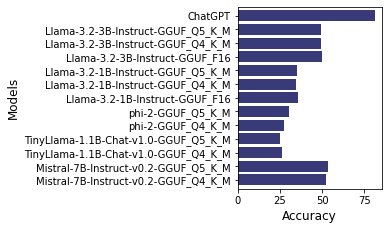

In [10]:
# Import plotting libraries used by the analysis figures.
import seaborn as sns
import matplotlib.pyplot as plt

# Select the Orin measurements and the cloud baseline, then convert accuracy to percentage values.
pivot = main_comparison_df[(main_comparison_df["device"]=="Orin") | (main_comparison_df["device"]=="Cloud")].set_index([ "model"]).accuracy * 100

# Plot model accuracy as a horizontal bar chart for easier comparison across model names.
ax = pivot.plot.barh(
    figsize=(5.5, 3.3),
    width=0.8,
    colormap="tab20b"
)

# Configure axis labels and layout.
ax.set_ylabel("Models", fontsize=12)
ax.set_xlabel("Accuracy", fontsize=12)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()

plt.show()

## Model footprint comparison

This plot compares the model file size in gigabytes for the Orin configurations and the cloud reference entry. The purpose is to show that model footprint is not sufficient on its own to predict deployment quality. In the paper, this supports the observation that architecture, quantization, and runtime behavior can matter as much as parameter count or model size.


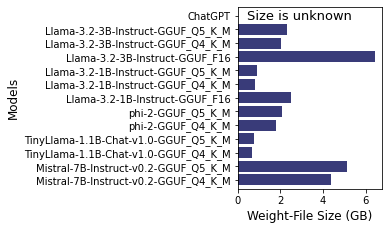

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import transforms
from matplotlib.patches import Rectangle

# Select model footprint values
pivot = main_comparison_df[
    (main_comparison_df["device"] == "Cloud") |
    (main_comparison_df["device"] == "Orin")
].set_index("model").model_size_GB

# Make sure ChatGPT is treated as unavailable
pivot.loc["ChatGPT"] = np.nan

# Plot normal values; NaN becomes zero-length
plot_values = pivot.fillna(0)

ax = plot_values.plot.barh(
    figsize=(5.5, 3.3),
    width=0.8,
    colormap="tab20b"
)

ax.set_ylabel("Models", fontsize=12)
ax.set_xlabel("Weight-File Size (GB)", fontsize=12)
ax.tick_params(axis="x", rotation=0)

# Add an N/A placeholder for models without a weight-file size
trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)

for i, (model, value) in enumerate(pivot.items()):
    if np.isnan(value):
        # Small bar-like box independent of the numerical x-axis
        # rect = Rectangle(
        #     (0.0, i - 0.4),
        #     0.10,       # 10% of plot width
        #     0.8,
        #     transform=trans,
        #     facecolor="lightgray",
        #     edgecolor="gray",
        #     hatch="//",
        #     zorder=3
        # )
        # ax.add_patch(rect)

        ax.text(
            .43,
            i,
            "Size is unknown",
            transform=trans,
            ha="center",
            va="center",
            fontsize=13,
            # fontweight="bold",
            zorder=4
        )

plt.tight_layout()
plt.show()

## Overall execution duration

This plot compares the total benchmark duration for the Orin configurations and the cloud reference. Duration summarizes the end-to-end time required to complete the workload, while the earlier prefill and decoding plots decompose latency into token-level components.


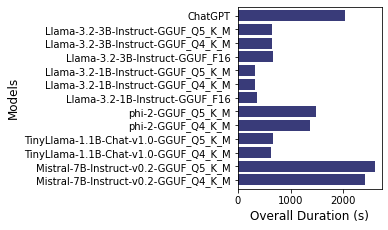

In [10]:
# Import plotting libraries used by the analysis figures.
import seaborn as sns
import matplotlib.pyplot as plt

# Select the end-to-end workload duration for the Orin measurements and the cloud baseline.
pivot = main_comparison_df[(main_comparison_df["device"]=="Orin") | (main_comparison_df["device"]=="Cloud")].set_index([ "model"]).duration_s

# Plot total duration as a horizontal bar chart to show complete benchmark runtime per model.
ax = pivot.plot.barh(
    figsize=(5.5, 3.3),
    width=0.8,
    colormap="tab20b"
)

# Configure axis labels and layout.
ax.set_ylabel("Models", fontsize=12)
ax.set_xlabel("Overall Duration (s)", fontsize=12)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()

plt.show()

## Accuracy-latency Pareto frontier with no added delivery overhead

This analysis builds the Pareto frontier using accuracy and decoding latency per generated token. The cloud reference is removed because the Pareto analysis focuses on self-hosted deployment choices. Accuracy is converted to percentage, and latency is kept as the measured compute-side decoding latency.

A configuration is Pareto-efficient when no other configuration has both lower latency and higher accuracy. This plot is used to identify dominated configurations that can be pruned because they do not provide a useful accuracy-latency trade-off.


/tmp/ipykernel_15134/116450093.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


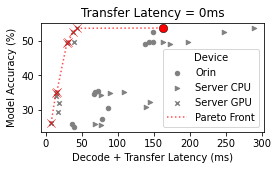

In [11]:
# Import the libraries required for data preparation, Pareto-front detection, and plotting.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Keep only the columns required for the accuracy-latency trade-off analysis.
all_models = (
    main_comparison_df[
        [
            "decode_latency_ms_per_token",
            "accuracy",
            "device",
            "model"
        ]
    ]
    .rename(columns={
        "decode_latency_ms_per_token": "latency_ms"
    })
    .copy()
)

# Exclude the cloud baseline because the Pareto analysis focuses on self-hosted edge-continuum deployments.
all_models = all_models[all_models["device"]!="Cloud"]

# Prepare the two optimization objectives, decode latency and accuracy, together with labels for plotting.
df = all_models[["latency_ms", "accuracy", "device", "model"]]

# Convert accuracy from a fraction to a percentage.
df["accuracy"] = 100 * df["accuracy"]  # Convert to percentage

# Add zero transfer overhead to server-side deployments for the compute-side baseline case.
df["latency_ms"] = df["latency_ms"] + df["device"].isin(["Server GPU", "Server CPU"]).astype(int)*0

# Define a distinct marker for each deployment platform.
device_markers = {
    'Server GPU': 'x',
    'Server CPU': '>',
    'Orin GPU': 'D',
    'Cloud': 's'
}


# Identify non-dominated configurations, where lower latency and higher accuracy are preferred.
def is_pareto_efficient(points):
    is_efficient = np.ones(points.shape[0], dtype=bool)
    for i, c in enumerate(points):
        is_dominated = np.any(
            (points[:, 0] <= c[0]) & 
            (points[:, 1] >= c[1]) & 
            ((points[:, 0] < c[0]) | (points[:, 1] > c[1]))
        )
        if is_dominated:
            is_efficient[i] = False
    return is_efficient

# Compute the Pareto frontier using latency as the minimization objective and accuracy as the maximization objective.
points = df[["latency_ms", "accuracy"]].values
is_pareto = is_pareto_efficient(points)
pareto_df = df[is_pareto].copy().sort_values("latency_ms")

# Plot all evaluated configurations in grey, grouped by device.
fig, ax = plt.subplots()
for device, group in df.groupby("device"):
    group.plot.scatter(
        x="latency_ms", 
        y="accuracy", 
        label=device,
        marker=device_markers.get(device, 'o'), 
        color="grey",
        ax=ax,
        figsize=(4, 2)
    )

# Highlight the Pareto-efficient configurations in red while preserving their device-specific markers.
for _, row in pareto_df.iterrows():
    ax.scatter(
        row["latency_ms"],
        row["accuracy"],
        color="red",
        marker=device_markers.get(row["device"], 'o'),
        s=70,
        edgecolors='black',
        linewidths=0.5
    )

# Connect the Pareto-efficient configurations to make the frontier easier to inspect visually.
ax.plot(
    pareto_df["latency_ms"].to_numpy(), 
    pareto_df["accuracy"].to_numpy(), 
    color="red", 
    linewidth=1.5,
    linestyle=":",
    alpha=0.7,
    label="Pareto Front"
)

# Configure the plot labels and title for the zero-transfer-overhead scenario.
ax.set_ylabel("Model Accuracy (%)")
plt.legend(title="Device")

plt.title("Transfer Latency = 0ms")
plt.show()


## Accuracy-latency Pareto frontier with 30 ms server-side delivery overhead

This analysis repeats the Pareto-frontier computation after adding an effective 30 ms per-token delivery overhead to server-side deployments. The adjustment is applied only to `Server GPU` and `Server CPU` entries, while Orin remains unchanged because it represents local on-device inference.

The purpose is to study how moderate streamed-token delivery overhead can reduce the apparent latency advantage of remote server execution when evaluating client-observed token arrival delay.


/tmp/ipykernel_15134/3465243612.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


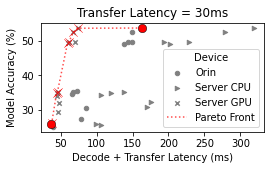

In [12]:
# Import the libraries required for data preparation, Pareto-front detection, and plotting.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Keep only the columns required for the accuracy-latency trade-off analysis.
all_models = (
    main_comparison_df[
        [
            "decode_latency_ms_per_token",
            "accuracy",
            "device",
            "model"
        ]
    ]
    .rename(columns={
        "decode_latency_ms_per_token": "latency_ms"
    })
    .copy()
)

# Exclude the cloud baseline because this sensitivity analysis compares local and near-edge self-hosted deployments.
all_models = all_models[all_models["device"]!="Cloud"]

# Prepare the analysis table with latency, accuracy, device, and model labels.
df = all_models[["latency_ms", "accuracy", "device", "model"]]

# Convert accuracy from a fraction to a percentage.
df["accuracy"] = 100 * df["accuracy"]  # Convert to percentage

# Add 30 ms of effective per-token delivery overhead to server-side deployments only.
df["latency_ms"] = df["latency_ms"] + df["device"].isin(["Server GPU", "Server CPU"]).astype(int)*30

# Define a distinct marker for each deployment platform.
device_markers = {
    'Server GPU': 'x',
    'Server CPU': '>',
    'Orin GPU': 'D',
    'Cloud': 's'
}


# Identify non-dominated configurations, where lower latency and higher accuracy are preferred.
def is_pareto_efficient(points):
    is_efficient = np.ones(points.shape[0], dtype=bool)
    for i, c in enumerate(points):
        is_dominated = np.any(
            (points[:, 0] <= c[0]) & 
            (points[:, 1] >= c[1]) & 
            ((points[:, 0] < c[0]) | (points[:, 1] > c[1]))
        )
        if is_dominated:
            is_efficient[i] = False
    return is_efficient

# Compute the Pareto frontier after adding the 30 ms streaming-delivery overhead.
points = df[["latency_ms", "accuracy"]].values
is_pareto = is_pareto_efficient(points)
pareto_df = df[is_pareto].copy().sort_values("latency_ms")

# Plot all evaluated configurations in grey, grouped by device.
fig, ax = plt.subplots()
for device, group in df.groupby("device"):
    group.plot.scatter(
        x="latency_ms", 
        y="accuracy", 
        label=device,
        marker=device_markers.get(device, 'o'), 
        color="grey",
        ax=ax,
        figsize=(4, 2)
    )

# Highlight the Pareto-efficient configurations in red while preserving their device-specific markers.
for _, row in pareto_df.iterrows():
    ax.scatter(
        row["latency_ms"],
        row["accuracy"],
        color="red",
        marker=device_markers.get(row["device"], 'o'),
        s=70,
        edgecolors='black',
        linewidths=0.5
    )

# Connect the Pareto-efficient configurations to make the frontier easier to inspect visually.
ax.plot(
    pareto_df["latency_ms"].to_numpy(), 
    pareto_df["accuracy"].to_numpy(), 
    color="red", 
    linewidth=1.5,
    linestyle=":",
    alpha=0.7,
    label="Pareto Front"
)

# Configure the plot labels and title for the 30 ms transfer-overhead scenario.
ax.set_xlabel("Decode + Transfer Latency (ms)")
ax.set_ylabel("Model Accuracy (%)")
plt.legend(title="Device")

plt.title("Transfer Latency = 30ms")
plt.show()


## Accuracy-latency Pareto frontier with 60 ms server-side delivery overhead

This final Pareto analysis uses a higher effective 60 ms per-token delivery overhead for server-side deployments. It represents a stronger sensitivity scenario for streamed responses in which token delivery, buffering, and client-side receipt add noticeable delay.

The comparison with the previous Pareto plots shows how deployment choices can shift toward local Orin execution for latency-sensitive cases, while server GPU configurations may remain useful for higher-accuracy points.


/tmp/ipykernel_15134/1026027298.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


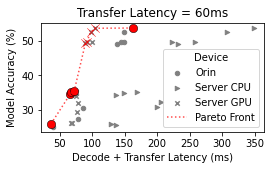

In [13]:
# Import the libraries required for data preparation, Pareto-front detection, and plotting.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Keep only the columns required for the accuracy-latency trade-off analysis.
all_models = (
    main_comparison_df[
        [
            "decode_latency_ms_per_token",
            "accuracy",
            "device",
            "model"
        ]
    ]
    .rename(columns={
        "decode_latency_ms_per_token": "latency_ms"
    })
    .copy()
)

# Exclude the cloud baseline because this sensitivity analysis compares local and near-edge self-hosted deployments.
all_models = all_models[all_models["device"]!="Cloud"]

# Prepare the analysis table with latency, accuracy, device, and model labels.
df = all_models[["latency_ms", "accuracy", "device", "model"]]

# Convert accuracy from a fraction to a percentage.
df["accuracy"] = 100 * df["accuracy"]  # Convert to percentage

# Add 60 ms of effective per-token delivery overhead to server-side deployments only.
df["latency_ms"] = df["latency_ms"] + df["device"].isin(["Server GPU", "Server CPU"]).astype(int)*60

# Define a distinct marker for each deployment platform.
device_markers = {
    'Server GPU': 'x',
    'Server CPU': '>',
    'Orin GPU': 'D',
    'Cloud': 's'
}


# Identify non-dominated configurations, where lower latency and higher accuracy are preferred.
def is_pareto_efficient(points):
    is_efficient = np.ones(points.shape[0], dtype=bool)
    for i, c in enumerate(points):
        is_dominated = np.any(
            (points[:, 0] <= c[0]) & 
            (points[:, 1] >= c[1]) & 
            ((points[:, 0] < c[0]) | (points[:, 1] > c[1]))
        )
        if is_dominated:
            is_efficient[i] = False
    return is_efficient

# Compute the Pareto frontier after adding the 60 ms streaming-delivery overhead.
points = df[["latency_ms", "accuracy"]].values
is_pareto = is_pareto_efficient(points)
pareto_df = df[is_pareto].copy().sort_values("latency_ms")

# Plot all evaluated configurations in grey, grouped by device.
fig, ax = plt.subplots()
for device, group in df.groupby("device"):
    group.plot.scatter(
        x="latency_ms", 
        y="accuracy", 
        label=device,
        marker=device_markers.get(device, 'o'), 
        color="grey",
        ax=ax,
        figsize=(4, 2)
    )

# Highlight the Pareto-efficient configurations in red while preserving their device-specific markers.
for _, row in pareto_df.iterrows():
    ax.scatter(
        row["latency_ms"],
        row["accuracy"],
        color="red",
        marker=device_markers.get(row["device"], 'o'),
        s=70,
        edgecolors='black',
        linewidths=0.5
    )

# Connect the Pareto-efficient configurations to make the frontier easier to inspect visually.
ax.plot(
    pareto_df["latency_ms"].to_numpy(), 
    pareto_df["accuracy"].to_numpy(), 
    color="red", 
    linewidth=1.5,
    linestyle=":",
    alpha=0.7,
    label="Pareto Front"
)

# Configure the plot labels and title for the 60 ms transfer-overhead scenario.
ax.set_xlabel("Decode + Transfer Latency (ms)")
ax.set_ylabel("Model Accuracy (%)")
plt.legend(title="Device")

plt.title("Transfer Latency = 60ms")
plt.show()
